In [ ]:
from pathlib import Path
import numpy as np
from pprint import pprint
from PIL import Image
import matplotlib.pyplot as plt
import json

from bovw import BagOfVisualWordsClassifier, BoVWConfig

In [ ]:
def get(feature_extractor, vocabulary_size, use_tfidf, method):
    dataset_root = Path('caltech101_reduced')

    config = BoVWConfig(
        feature_extractor=feature_extractor,
        vocabulary_size=vocabulary_size,
        max_descriptors_per_image=250,
        max_vocabulary_descriptors=20000,
        random_state=42,
    )
    model = BagOfVisualWordsClassifier(config)
    model.fit(dataset_root / 'train')

    test_images = sorted([p for p in (dataset_root / 'test').rglob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}])

    model.index_dataset(test_images, use_tfidf=use_tfidf)

    results = model.evaluate_retrieval(test_images, top_k=8, metric=method, use_tfidf=use_tfidf)
    print('Mean Precision@8: {:.4f}'.format(results['mean_precision_at_k']))
    print('Mean Recall@8: {:.4f}'.format(results['mean_recall_at_k']))
    print('Mean Average Precision (mAP): {:.4f}'.format(results['mean_average_precision']))

    return results['mean_precision_at_k']

In [ ]:
x = ['SIFT', 'ORB', 'AKAZE', 'BRISK', 'KAZE']
y = []
for i in x:
    print(i)
    y.append(get(i, 100, True, "cosine"))

In [ ]:
import numpy as np

x = np.array(x)
y = np.array(y)

indices = np.argsort(y)[::-1]
x_sorted = x[indices]
y_sorted = y[indices]

plt.bar(x_sorted, y_sorted, color='skyblue', edgecolor='black')
plt.title('Feature Extraction Comparison', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [ ]:
with open("results.json", 'r') as f:
    data = json.load(f)

In [ ]:
x = ["50", "100", "500"]
y = [data["50k"]["mAp"], data["100k"]["mAp"], data["500k"]["mAp"]]

plt.bar(x, y, color='skyblue', edgecolor='black')

plt.xlabel('k', fontsize=12)
plt.title('Vocabulary Size', fontsize=14)

plt.tight_layout()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x_names_raw = list(data["500k"]["recall"].keys())

combined = []
for name in x_names_raw:
    combined.append((
        name, 
        data["50k"]["recall"][name], 
        data["100k"]["recall"][name], 
        data["500k"]["recall"][name]
    ))

combined.sort(key=lambda x: x[3], reverse=True)

x_names = [item[0] for item in combined]
vals_50k = [item[1] for item in combined]
vals_100k = [item[2] for item in combined]
vals_500k = [item[3] for item in combined]

x = np.arange(len(x_names))
width = 0.25

fig, ax = plt.subplots(figsize=(15, 7))

ax.bar(x - width, vals_50k, width, label='50k', color='#1f77b4')
ax.bar(x,         vals_100k, width, label='100k', color='#ff7f0e')
ax.bar(x + width, vals_500k, width, label='500k', color='#2ca02c')

ax.set_ylabel('Recall')
ax.set_title('Recall posortowany według modelu 500k')
ax.set_xticks(x)
ax.set_xticklabels(x_names, rotation=90)
ax.legend(title="Vocabulary Size")

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x_names_raw = list(["windsor_chair", "gerenuk", "stop_sign", "Leopards", "butterfly", "octopus"])

combined = []
for name in x_names_raw:
    combined.append((
        name, 
        data["50k"]["recall"][name], 
        data["100k"]["recall"][name], 
        data["500k"]["recall"][name]
    ))

combined.sort(key=lambda x: x[3], reverse=True)

x_names = [item[0] for item in combined]
vals_50k = [item[1] for item in combined]
vals_100k = [item[2] for item in combined]
vals_500k = [item[3] for item in combined]

x = np.arange(len(x_names))
width = 0.25

fig, ax = plt.subplots(figsize=(15, 7))

ax.bar(x - width, vals_50k, width, label='50', color='#1f77b4')
ax.bar(x,         vals_100k, width, label='100', color='#ff7f0e')
ax.bar(x + width, vals_500k, width, label='500', color='#2ca02c')

ax.set_ylabel('Recall')
ax.set_title('Recall wybranych')
ax.set_xticks(x)
ax.set_xticklabels(x_names, rotation=90)
ax.legend(title="Vocabulary Size")

plt.tight_layout()
plt.show()

Zarówno Windsor_chair jak i gerenuk mają charakterystyczny kształt, jednak gerenuk na prawie wszystkich zdjęciach znajduje się na tle trawy. Przez to program często myli go z innymi zwierzętami, bo uczy się tekstury tła zamiast samego obiektu. Windsor_chair z kolei występuje zazwyczaj na czystym, białym tle, co ułatwia programowi wyodrębnienie jego specyficznych cech.

Dla leopards zwiększenie rozmiaru słownika znacząco zmniejszyło dokładność. Najprawdopodobniej stało się tak dlatego, że program przy większej liczbie słów wizualnych zaczął zbyt szczegółowo reagować na wzór ciemne punkty na jasnym tle.

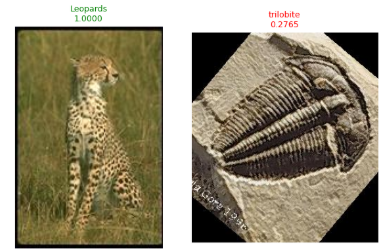

Program kompletnie nie poradził sobie z klasami butterfly oraz octopus. Wynika to z ogromnej zmienności wewnątrz tych grup – ośmiornice i motyle mają bardzo różne kolory, wzory, a przede wszystkim kształty.

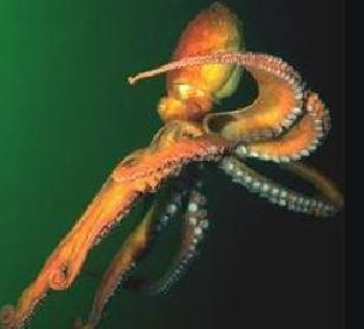
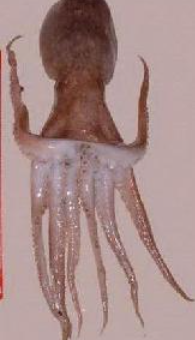
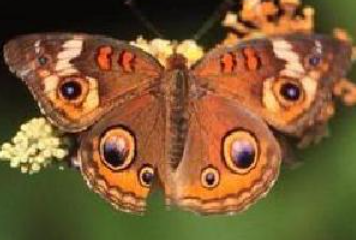
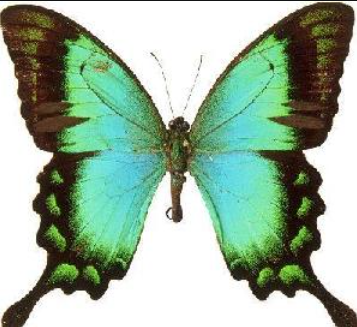

In [ ]:
x = ["cosine", "l2"]
y = [data["500k"]["mAp"], data["500k-l2"]["mAp"]]

plt.bar(x, y, color='skyblue', edgecolor='black')

plt.title('Consine vs L2', fontsize=14)

plt.tight_layout()

In [ ]:
x = ["TF", "TF-IDF"]
y = [data["500k-tf"]["mAp"], data["500k"]["mAp"]]

plt.bar(x, y, color='skyblue', edgecolor='black')

plt.title('TF vs TF-IDF', fontsize=14)

plt.tight_layout()

In [ ]:
def get(vocabulary_size, use_tfidf, method):
    dataset_root = Path('caltech101_reduced')
    feature_extractor = 'SIFT'

    config = BoVWConfig(
        feature_extractor=feature_extractor,
        vocabulary_size=vocabulary_size,
        max_descriptors_per_image=250,
        max_vocabulary_descriptors=20000,
        random_state=42,
    )
    model = BagOfVisualWordsClassifier(config)
    print('Training...')
    model.fit(dataset_root / 'train')
    print('Training finished.')

    test_images = sorted([p for p in (dataset_root / 'test').rglob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}])
    print(f'Found {len(test_images)} test images to index')

    print('Indexing... (this may take a while)')
    model.index_dataset(test_images, use_tfidf=use_tfidf)
    print('Index built. Indexed features shape:', getattr(model, '_index_features').shape)

    results = model.evaluate_retrieval(test_images, top_k=8, metric=method, use_tfidf=use_tfidf)
    print('Mean Precision@8: {:.4f}'.format(results['mean_precision_at_k']))
    print('Mean Recall@8: {:.4f}'.format(results['mean_recall_at_k']))
    print('Mean Average Precision (mAP): {:.4f}'.format(results['mean_average_precision']))

    result = {}

    result["mAP"] = results['mean_average_precision']
    result["recall"] = {}

    for el in results['per_query']:
        result["recall"][el["query"]] = el["recall_at_k"]
        print(f"{el["query"]}:{el["recall_at_k"]}")

    return result

In [ ]:
resutls1 = get(100, True, "l2")

In [ ]:
results2 = get(100, True, "cosine")

In [ ]:
results3 = get(100, False, "cosine")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x_names_raw = list(results3["recall"].keys())

combined = []
for name in x_names_raw:
    combined.append((
        "\\".join(name.split("\\")[2:]), 
        results2["recall"][name], 
        results3["recall"][name]
    ))

combined.sort(key=lambda x: x[1], reverse=True)

x_names = [item[0] for item in combined]
vals_50k = [item[1] for item in combined]
vals_100k = [item[2] for item in combined]

x = np.arange(len(x_names))
width = 0.25

fig, ax = plt.subplots(figsize=(15, 7))

ax.bar(x - width, vals_50k, width, label='tf-idf', color='#1f77b4')
ax.bar(x,         vals_100k, width, label='tf', color='#ff7f0e')

ax.set_ylabel('Recall')
ax.set_title('Recall posortowany')
ax.set_xticks(x)
ax.set_xticklabels(x_names, rotation=90)
ax.legend(title="Vocabulary Size")

plt.tight_layout()
plt.show()

In [ ]:
dataset_root = Path('caltech101_reduced')
feature_extractor = 'SIFT'

config = BoVWConfig(
    feature_extractor=feature_extractor,
    vocabulary_size=100,
    max_descriptors_per_image=250,
    max_vocabulary_descriptors=20000,
    random_state=42,
)
model = BagOfVisualWordsClassifier(config)
model.fit(dataset_root / 'train')

test_images = sorted([p for p in (dataset_root / 'test').rglob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}])

print('Indexing... (this may take a while)')
model.index_dataset(test_images, use_tfidf=False)

In [ ]:
query_idx = 3
query_path = test_images[query_idx]
    
results = model.query(query_path, top_k=8, metric='cosine', use_tfidf=False)

n = len(results) + 1
fig, axes = plt.subplots(1, n, figsize=(3 * n, 4))

qimg = Image.open(query_path).convert('RGB')
axes[0].imshow(qimg)
axes[0].set_title(f'Query ({query_idx})\n{query_path.parent.name}', fontsize=10, color='blue')
axes[0].axis('off')

for i, (p, score) in enumerate(results, start=1):
    img = Image.open(p).convert('RGB')
    axes[i].imshow(img)
    
    is_correct = p.parent.name == query_path.parent.name
    title_color = 'green' if is_correct else 'red'
    
    axes[i].set_title(f'{p.parent.name}\n{score:.4f}', fontsize=9, color=title_color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Bez ważenia histogramu algorytm dla powyższego przypadku skupił się na kontraście (czerń vs biel). Dla niektórych przypadków wynik zmalał, bo unikalne cechy obiektu zostały zbyt mocno stłumione. Jednak ogólnie zwiększył dokładność

In [ ]:
dataset_root = Path('dataset')
feature_extractor = 'SIFT' 
vocabulary_size = 500      
use_tfidf = True            

config = BoVWConfig(
    feature_extractor=feature_extractor,
    vocabulary_size=vocabulary_size,
    max_descriptors_per_image=2000,
    max_vocabulary_descriptors=5000000,
    random_state=42,
)
model = BagOfVisualWordsClassifier(config)

print('Training...')
model.fit(dataset_root / 'train')
print('Training finished.')

In [34]:
test_images = sorted([p for p in (dataset_root / 'test').rglob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}])
test_images.append("./mine1.jpg")
test_images.append("./mine2.jpg")
test_images.append("./mine3.jpg")
print(f'Found {len(test_images)} test images to index')


print('Indexing... (this may take a while)')
model.index_dataset(test_images, use_tfidf=use_tfidf)
print('Index built. Indexed features shape:', getattr(model, '_index_features').shape)

Found 213 test images to index
Indexing... (this may take a while)
Index built. Indexed features shape: (213, 500)


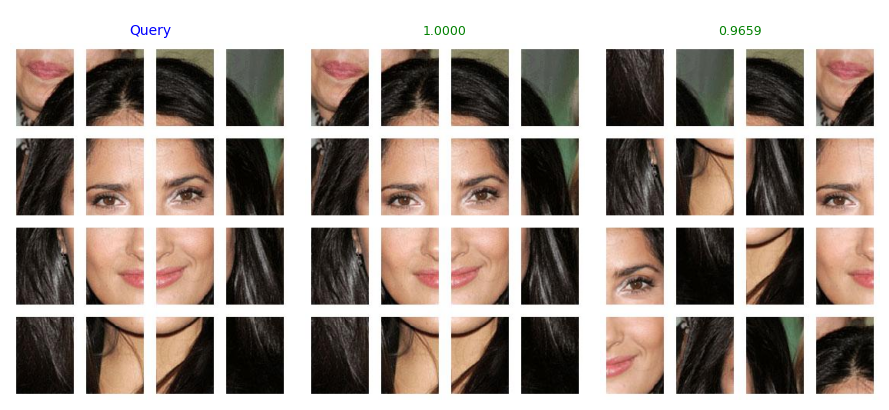

In [35]:
query_path = "./mine2.jpg"
results = model.query(query_path, top_k=8, metric='cosine', use_tfidf=use_tfidf)
n = len(results) + 1
n = 3
fig, axes = plt.subplots(1, n, figsize=(3 * n, 4))

qimg = Image.open(query_path).convert('RGB')
axes[0].imshow(qimg)
axes[0].set_title(f'Query', fontsize=10, color='blue')
axes[0].axis('off')

mine = []

mine.append(results[0])
mine.append(results[1])

for i, (p, score) in enumerate(mine, start=1):
    img = Image.open(p).convert('RGB')
    axes[i].imshow(img)
    
    title_color = 'green'
    
    axes[i].set_title(f'{p.parent.name}\n{score:.4f}', fontsize=9, color=title_color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Inną wadą metody BoVW jest ignorowanie informacji o przestrzennym rozmieszczeniu cech.

SIFT wykrywa interesujące punkty na podstawie kontrastu dlatego dodaliśmy białe linie by pomieszanie fragmentów nie spowodowało że nowe granice tworzą kontrast (teraz tylko graniczą kolorem białym)
Pomieszanie fragmentów praktycznie według algorytmu jest identyczne do orginału, bo wykrywane punkty się nie zmieniają

In [187]:
# test_images = sorted([p for p in (dataset_root / 'test').rglob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}])
test_images = []
test_images.append("./mine1.jpg")
# test_images.append("./mine4.jpg")
test_images.append("./mine5.jpg")
test_images.append("./mine6.jpg")
test_images.append("./mine8.jpg")
print(f'Found {len(test_images)} test images to index')


print('Indexing... (this may take a while)')
model.index_dataset(test_images, use_tfidf=use_tfidf)
print('Index built. Indexed features shape:', getattr(model, '_index_features').shape)

Found 4 test images to index
Indexing... (this may take a while)
Index built. Indexed features shape: (4, 500)


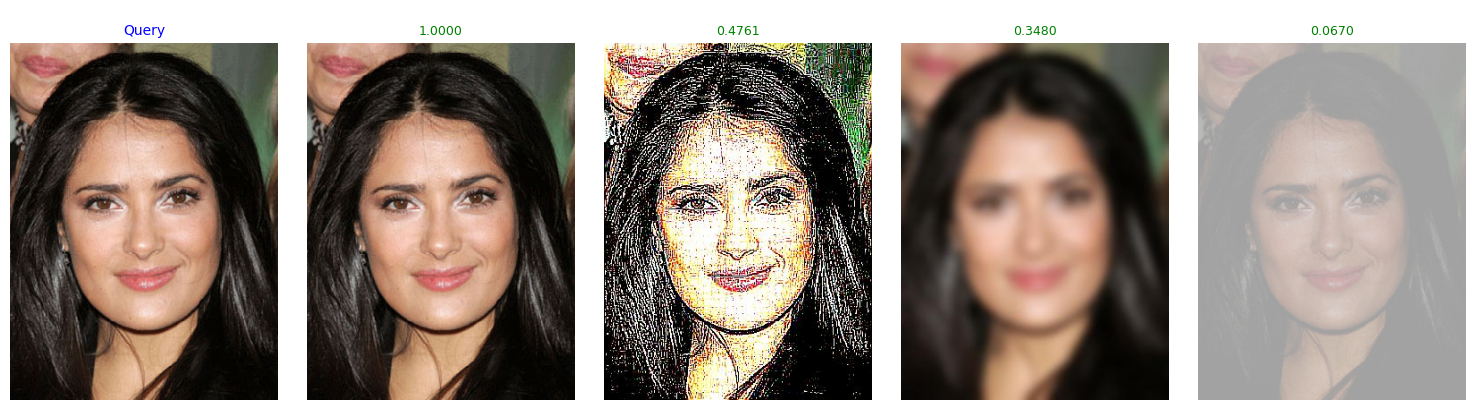

In [189]:
query_path = "./mine1.jpg"
results = model.query(query_path, top_k=8, metric='cosine', use_tfidf=use_tfidf)
n = len(results) + 1
n = 5
fig, axes = plt.subplots(1, n, figsize=(3 * n, 4))

qimg = Image.open(query_path).convert('RGB')
axes[0].imshow(qimg)
axes[0].set_title(f'Query', fontsize=10, color='blue')
axes[0].axis('off')

mine = []

for result in results:
    mine.append(result)

# mine.append(results[0])
# mine.append(results[1])
# mine.append(results[2])

for i, (p, score) in enumerate(mine, start=1):
    img = Image.open(p).convert('RGB')
    axes[i].imshow(img)
    
    title_color = 'green'
    
    axes[i].set_title(f'{p.parent.name}\n{score:.4f}', fontsize=9, color=title_color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Sprawdziliśmy, jak algorytm radzi sobie z deformacjami. Okazało się, że dopóki najważniejsze cechy są rozpoznawalne, detekcja przebiega pomyślnie. Algorytm jest jednak bardzo wrażliwy na zmiany kontrastu (ponieważ SIFT opiera się właśnie na nim). Gdy zmniejszyliśmy kontrast, algorytm całkowicie przestał rozpoznawać obiekt, mimo że dla ludzkiego oka twarz była dość dobrze rozpoznawalna.